# **Machine Learning Case Studies - 3**

## **Session Agenda**

During this session, we will explore the following **Feature Selection techniques** through practical case studies:

- Forward Selection
- Backward Elimination
- Exhaustive Feature Selection
- Elastic Net Feature Selection
- Decision Tree Feature Importance
- Feature Selection Evaluation and Performance Analysis

## **Learning Objectives**

By the end of this session, you will be able to:

- Understand the concepts of wrapper and embedded feature selection methods.
- Apply Forward Selection and Backward Elimination for selecting relevant features.
- Identify the optimal feature subset using Exhaustive Feature Selection.
- Perform feature selection using Elastic Net regularization.
- Interpret feature importance scores generated by Decision Tree models.
- Evaluate and compare feature selection techniques based on model performance and accuracy.

### **Importing the necessary libraries**

In [2]:
# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Dataset Generation
from sklearn.datasets import make_classification, make_regression

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeClassifier

# Feature Selection
from sklearn.feature_selection import SequentialFeatureSelector

# Performance Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    mean_squared_error,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Utility
from itertools import combinations

# **Case Study 1: Forward Feature Selection**

### **Problem Statement**

A bank wants to predict whether a customer will default on a loan using customer financial information. The objective is to select the most relevant features using the **Forward Selection** feature selection method.

### **Dataset**

| Feature | Description |
|---------|-------------|
| X1 | Annual Income |
| X2 | Credit Score |
| X3 | Number of Credit Cards |
| X4 | Existing Loan Amount |
| X5 | Age |
| X6 | Number of Dependents |

### **Target Variable**

- Loan Default (0 / 1)

### **Validation AUC Scores**

| Feature | AUC |
|---------|----:|
| X1 | 0.68 |
| X2 | 0.74 |
| X3 | 0.61 |
| X4 | 0.72 |
| X5 | 0.58 |
| X6 | 0.55 |

### **Tasks**

1. Perform Forward Feature Selection.
2. Select the best feature in each step.
3. Continue until the improvement in AUC is less than **0.01**.

## **i. Mathematical Computation**

### **Step 1: Initial Model**

Initially, no features are selected.

Initial AUC:

$$
AUC_0 = 0.50
$$


### **Step 2: Evaluate Each Feature Individually**

| Feature | AUC |
|---------|----:|
| $X_1$ | 0.68 |
| $X_2$ | **0.74** |
| $X_3$ | 0.61 |
| $X_4$ | 0.72 |
| $X_5$ | 0.58 |
| $X_6$ | 0.55 |

Select the feature with the highest AUC:

$$
\max(0.68,\;0.74,\;0.61,\;0.72,\;0.58,\;0.55)=0.74
$$

Therefore,

$$
\boxed{\text{Selected Feature}=X_2}
$$

Current Best AUC:

$$
AUC=0.74
$$


### **Step 3: Evaluate Addition of Remaining Features**

| Feature Set | AUC |
|-------------|----:|
| $X_2+X_1$ | 0.79 |
| $X_2+X_3$ | 0.75 |
| $X_2+X_4$ | **0.81** |
| $X_2+X_5$ | 0.76 |
| $X_2+X_6$ | 0.75 |

Choose the highest AUC:

$$
\max(0.79,\;0.75,\;0.81,\;0.76,\;0.75)=0.81
$$

Therefore,

$$
\boxed{\text{Selected Feature}=X_4}
$$

Current Feature Set:

$$
\boxed{\{X_2,\;X_4\}}
$$

Current Best AUC:

$$
AUC=0.81
$$

### **Step 4: Compute Improvement**

Previous AUC:

$$
AUC_{\text{previous}}=0.74
$$

Current AUC:

$$
AUC_{\text{current}}=0.81
$$

Improvement:

$$
\Delta AUC=AUC_{\text{current}}-AUC_{\text{previous}}
$$

$$
\Delta AUC=0.81-0.74=0.07
$$

Threshold:

$$
T=0.01
$$

Since,

$$
0.07>0.01
$$

Therefore,

$$
\boxed{\text{Continue Forward Selection}}
$$

### **Final Selected Features**

$$
\boxed{X_2,\;X_4}
$$

### **Final Validation AUC**

$$
\boxed{0.81}
$$

## **ii. Code Implementation**

Load the initial AUC value before starting the Forward Selection process.

In [3]:
# Initial AUC
initial_auc = 0.50
print("Initial AUC:", initial_auc)

Initial AUC: 0.5


Create a table containing the individual AUC scores for all available features and identify the feature with the highest AUC and select it as the first feature.

In [4]:
single_auc = {
    "X1": 0.68,
    "X2": 0.74,
    "X3": 0.61,
    "X4": 0.72,
    "X5": 0.58,
    "X6": 0.55
}

df = pd.DataFrame(single_auc.items(), columns=["Feature", "AUC"])
df

,Feature,AUC
0,X1,0.68
1,X2,0.74
2,X3,0.61
3,X4,0.72
4,X5,0.58
5,X6,0.55


In [5]:
# Select the feature with the highest AUC
selected_feature = max(single_auc, key=single_auc.get)
best_auc = single_auc[selected_feature]

print("Selected Feature:", selected_feature)
print("Best AUC:", best_auc)

Selected Feature: X2
Best AUC: 0.74


Evaluate the AUC scores obtained by combining the selected feature with each remaining feature. Select the feature combination that produces the highest validation AUC.

In [6]:
# Evaluate remaining features
pair_auc = {
    "X2 + X1": 0.79,
    "X2 + X3": 0.75,
    "X2 + X4": 0.81,
    "X2 + X5": 0.76,
    "X2 + X6": 0.75
}

df_pair = pd.DataFrame(pair_auc.items(), columns=["Feature Set", "AUC"])
df_pair

,Feature Set,AUC
0,X2 + X1,0.79
1,X2 + X3,0.75
2,X2 + X4,0.81
3,X2 + X5,0.76
4,X2 + X6,0.75


In [7]:
# Selecting the best feature combination
selected_pair = max(pair_auc, key=pair_auc.get)
new_auc = pair_auc[selected_pair]

print("Selected Feature Set:", selected_pair)
print("Best AUC:", new_auc)

Selected Feature Set: X2 + X4
Best AUC: 0.81


Calculate the improvement in AUC and compare it with the stopping threshold. Display the final selected features and the corresponding validation AUC.

In [8]:
# Check threshold for improvement
threshold = 0.01
improvement = round(new_auc - best_auc, 2)

print("Improvement:", improvement)

if improvement > threshold:
    print("Continue Forward Selection")
else:
    print("Stop Forward Selection")


print("\nFinal Selected Features: X2, X4")
print("Final Validation AUC:", new_auc)

Improvement: 0.07
Continue Forward Selection

Final Selected Features: X2, X4
Final Validation AUC: 0.81


## **iii. Visual Analysis**

The line charts show that **X2 (Credit Score)** has the highest individual AUC (**0.74**). After adding another feature, **X2 + X4** achieves the highest AUC (**0.81**), making it the best feature combination.

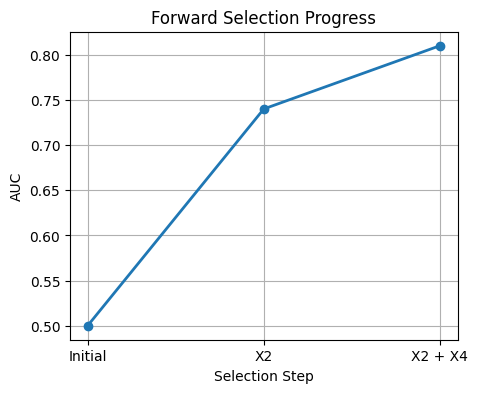

In [9]:
# Visualizing the Forward Selection Process
steps = ["Initial", "X2", "X2 + X4"]
auc = [0.50, 0.74, 0.81]

plt.figure(figsize=(5,4))
plt.plot(steps, auc, marker='o', linewidth=2)
plt.title("Forward Selection Progress")
plt.xlabel("Selection Step")
plt.ylabel("AUC")
plt.grid(True)
plt.show()

## **iv. Questions & Answers**

### **1. Which feature gets selected first?**
  
**X2 (Credit Score)** is selected first because it achieves the highest individual validation AUC of **0.74**, making it the most informative feature in the first iteration.


### **2. Which feature is selected in Step 2?**
  
**X4 (Existing Loan Amount)** is selected in the second step because the combination **X2 + X4** produces the highest validation AUC of **0.81**, outperforming all other feature combinations.


### **3. Continue if the threshold improvement is 0.01.**

Yes. The AUC increases from **0.74** to **0.81**, resulting in an improvement of **0.07**.

$$
0.81 - 0.74 = 0.07
$$

Since **0.07 > 0.01**, the improvement exceeds the threshold. Therefore, the **Forward Selection process continues** with the selected feature set **{X2, X4}**.

**Note:**

The improvement from **0.74** to **0.81** is:

$$
0.81 - 0.74 = 0.07 > 0.01
$$

Therefore, the Forward Selection process should continue. However, the validation AUC values for the next iteration are not provided, so the remaining feature selection steps cannot be performed.

# **Case Study 2: Backward Elimination**

### **Problem Statement**

A healthcare company wants to predict the hospitalization cost of patients using various health-related features. The objective is to remove statistically insignificant features using the **Backward Elimination** feature selection method.

### **Dataset**

| Feature | Description |
|---------|-------------|
| Age | Patient Age |
| BMI | Body Mass Index |
| Blood Pressure | Blood Pressure Level |
| Smoking | Smoking Status |
| Exercise | Exercise Hours |
| Alcohol | Alcohol Consumption |
| Cholesterol | Cholesterol Level |

### **Target Variable**

- Hospitalization Cost

### **Significance Level**

$\alpha$ = 0.05


### **Linear Regression Results**

| Variable | p-value |
|----------|--------:|
| Age | 0.0001 |
| BMI | 0.004 |
| Blood Pressure | 0.15 |
| Smoking | 0.0003 |
| Exercise | 0.18 |
| Alcohol | 0.62 |
| Cholesterol | 0.01 |

### **Task**

Perform **Backward Elimination** using a significance level of **0.05**.

## **i. Mathematical Computation**

Significance Level:

$$
\alpha = 0.05
$$

Initial Features:

$$
\{Age,\ BMI,\ Blood\ Pressure,\ Smoking,\ Exercise,\ Alcohol,\ Cholesterol\}
$$

### **Iteration 1**

Highest p-value:

$$
\max(0.0001,\ 0.004,\ 0.15,\ 0.0003,\ 0.18,\ 0.62,\ 0.01)=0.62
$$

$$
\boxed{\text{Remove Alcohol}}
$$

### **Iteration 2**

Remaining p-values:

$$
0.0001,\ 0.004,\ 0.15,\ 0.0003,\ 0.18,\ 0.01
$$

Highest p-value:

$$
0.18 > 0.05
$$

$$
\boxed{\text{Remove Exercise}}
$$

### **Iteration 3**

Remaining p-values:

$$
0.0001,\ 0.004,\ 0.15,\ 0.0003,\ 0.01
$$

Highest p-value:

$$
0.15 > 0.05
$$

$$
\boxed{\text{Remove Blood Pressure}}
$$


### **Final Selected Features**

Remaining p-values:

$$
0.0001,\ 0.004,\ 0.0003,\ 0.01
$$

Since all remaining p-values satisfy

$$
p < 0.05
$$

the Backward Elimination process stops.

$$
\boxed{\{Age,\ BMI,\ Smoking,\ Cholesterol\}}
$$

## **ii. Coding Implementation**

Create the p-value dataset

In [10]:
# Creating a DataFrame for p-values of features
data = {
    "Feature": ["Age", "BMI", "Blood Pressure", "Smoking", "Exercise", "Alcohol", "Cholesterol"],
    "p-value": [0.0001, 0.004, 0.15, 0.0003, 0.18, 0.62, 0.01]
}

df = pd.DataFrame(data)
df

,Feature,p-value
0,Age,0.0001
1,BMI,0.0040
2,Blood Pressure,0.1500
3,Smoking,0.0003
4,Exercise,0.1800
5,Alcohol,0.6200
6,Cholesterol,0.0100


Perform Backward Elimination

In [11]:
# Performing Backward Elimination
alpha = 0.05
iteration = 1

print("Initial Features\n")
print(df)

while df["p-value"].max() > alpha:

    highest = df["p-value"].idxmax()
    removed_feature = df.loc[highest, "Feature"]
    removed_pvalue = df.loc[highest, "p-value"]

    df = df.drop(highest).reset_index(drop=True)

    print(f"\nIteration {iteration}")
    print(f"Removed Feature : {removed_feature} (p-value = {removed_pvalue})")
    print("Remaining Features:", df["Feature"].tolist())

    iteration += 1

print("\nBackward Elimination Completed")

Initial Features

          Feature  p-value
0             Age   0.0001
1             BMI   0.0040
2  Blood Pressure   0.1500
3         Smoking   0.0003
4        Exercise   0.1800
5         Alcohol   0.6200
6     Cholesterol   0.0100

Iteration 1
Removed Feature : Alcohol (p-value = 0.62)
Remaining Features: ['Age', 'BMI', 'Blood Pressure', 'Smoking', 'Exercise', 'Cholesterol']

Iteration 2
Removed Feature : Exercise (p-value = 0.18)
Remaining Features: ['Age', 'BMI', 'Blood Pressure', 'Smoking', 'Cholesterol']

Iteration 3
Removed Feature : Blood Pressure (p-value = 0.15)
Remaining Features: ['Age', 'BMI', 'Smoking', 'Cholesterol']

Backward Elimination Completed


In [12]:
# Print the final selected features
print("Final Selected Features:")

for feature in df["Feature"].tolist():
    print(feature)

Final Selected Features:
Age
BMI
Smoking
Cholesterol


## **iii. Visual Analysis**

The bar chart compares the p-values of all features with the significance level of **0.05** (red dashed line). Features with p-values **above 0.05**—**Alcohol, Exercise, and Blood Pressure**—are considered statistically insignificant and are removed during Backward Elimination. The remaining features (**Age, BMI, Smoking, and Cholesterol**) have p-values **below the significance level** and are retained in the final regression model.

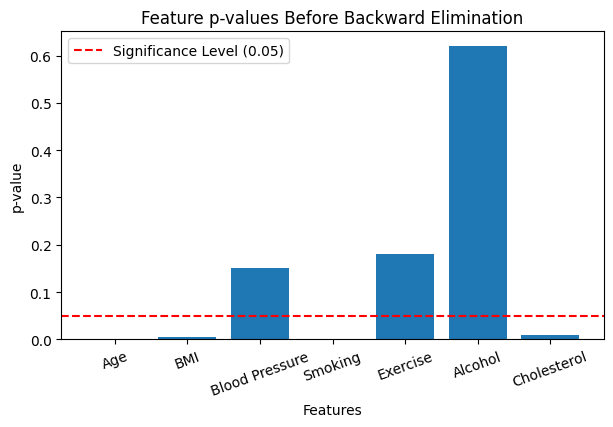

In [13]:
# Visualizing the p-values of features before backward elimination
plt.figure(figsize=(7,4))

plt.bar(data["Feature"], data["p-value"])
plt.axhline(y=0.05, linestyle="--", color="red", label="Significance Level (0.05)")

plt.title("Feature p-values Before Backward Elimination")
plt.xlabel("Features")
plt.ylabel("p-value")
plt.xticks(rotation=20)
plt.legend()

plt.show()

## **iv. Questions & Answers**

### **1. Perform Backward Elimination.**

Using a significance level of **0.05**, features with the highest p-values are removed iteratively until all remaining features have **p-values less than 0.05**.

- **Iteration 1:** Remove **Alcohol** (p-value = 0.62)
- **Iteration 2:** Remove **Exercise** (p-value = 0.18)
- **Iteration 3:** Remove **Blood Pressure** (p-value = 0.15)

The Backward Elimination process stops because all remaining features satisfy the significance criterion.

**Final Selected Features:**
- Age
- BMI
- Smoking Status
- Cholesterol

### **2. Why were Alcohol, Exercise, and Blood Pressure removed from the model?**

These features were removed because their **p-values exceeded the significance level of 0.05**, indicating that they were not statistically significant predictors in the regression model. Removing them simplifies the model while retaining only the most relevant features.

# **Case Study 3: Exhaustive Feature Selection**

### **Problem Statement**

An e-commerce company wants to predict whether a customer will churn based on customer behavior. The objective is to identify the **best combination of three features** using **Exhaustive Feature Selection**, which evaluates every possible feature combination.

### **Dataset**

| Feature | Description |
|---------|-------------|
| Purchase Frequency (PF) | Number of purchases made |
| Average Basket Value (ABV) | Average order value |
| Visits Per Month | Monthly website visits |
| Customer Tenure | Years as customer |
| Discount Usage | Frequency of using discounts |
| Email Opens | Marketing email engagement |

### **Target Variable**

- Customer Churn (Yes / No)

### **Validation Accuracy**

| Feature Combination | Accuracy |
|---------------------|---------:|
| PF, ABV, Visits | 84% |
| PF, ABV, Tenure | 88% |
| PF, ABV, Discount | 82% |
| PF, ABV, Email | 83% |
| PF, Visits, Tenure | 87% |
| PF, Tenure, Email | 85% |
| PF, Discount, Email | 80% |
| ABV, Visits, Tenure | 86% |
| Visits, Tenure, Email | 84% |
| Tenure, Discount, Email | 78% |

### **Task**

Use **Exhaustive Feature Selection** to determine the best set of **3 features**.

## **i. Mathematical Computation**

Required number of features:

$$
k = 3
$$

Validation Accuracies:

| Feature Combination | Accuracy |
|---------------------|---------:|
| PF, ABV, Visits | 84% |
| PF, ABV, Tenure | **88%** |
| PF, ABV, Discount | 82% |
| PF, ABV, Email | 83% |
| PF, Visits, Tenure | 87% |
| PF, Tenure, Email | 85% |
| PF, Discount, Email | 80% |
| ABV, Visits, Tenure | 86% |
| Visits, Tenure, Email | 84% |
| Tenure, Discount, Email | 78% |

Select the combination with the highest validation accuracy:

$$
\max(84,\;88,\;82,\;83,\;87,\;85,\;80,\;86,\;84,\;78)=88
$$

Therefore,

$$
\boxed{\{PF,\ ABV,\ Tenure\}}
$$

Final Validation Accuracy:

$$
\boxed{88\%}
$$

## **ii. Code Implementation**

Create a dataset containing all possible feature combinations and their validation accuracies.

In [14]:
# Creating a DataFrame for feature combinations and their corresponding accuracy
data = {
    "Feature Combination": [
        "PF, ABV, Visits",
        "PF, ABV, Tenure",
        "PF, ABV, Discount",
        "PF, ABV, Email",
        "PF, Visits, Tenure",
        "PF, Tenure, Email",
        "PF, Discount, Email",
        "ABV, Visits, Tenure",
        "Visits, Tenure, Email",
        "Tenure, Discount, Email"
    ],
    "Accuracy %": [84, 88, 82, 83, 87, 85, 80, 86, 84, 78]
}

df = pd.DataFrame(data)
df

,Feature Combination,Accuracy %
0,"PF, ABV, Visits",84
1,"PF, ABV, Tenure",88
2,"PF, ABV, Discount",82
3,"PF, ABV, Email",83
4,"PF, Visits, Tenure",87
5,"PF, Tenure, Email",85
6,"PF, Discount, Email",80
7,"ABV, Visits, Tenure",86
8,"Visits, Tenure, Email",84
9,"Tenure, Discount, Email",78


Identify the feature combination with the highest validation accuracy.

In [15]:
# Select the best feature combination based on highest accuracy
best = df.loc[df["Accuracy %"].idxmax()]

print("Selected Feature Combination:")
print(best["Feature Combination"])
print("Validation Accuracy:", best["Accuracy %"], "%")

Selected Feature Combination:
PF, ABV, Tenure
Validation Accuracy: 88 %


## **iii. Visual Analysis**

The validation accuracies of all possible three-feature combinations are compared. The combination **Purchase Frequency, Average Basket Value, and Customer Tenure** achieves the highest accuracy of **88%**, making it the optimal feature subset selected using Exhaustive Feature Selection.

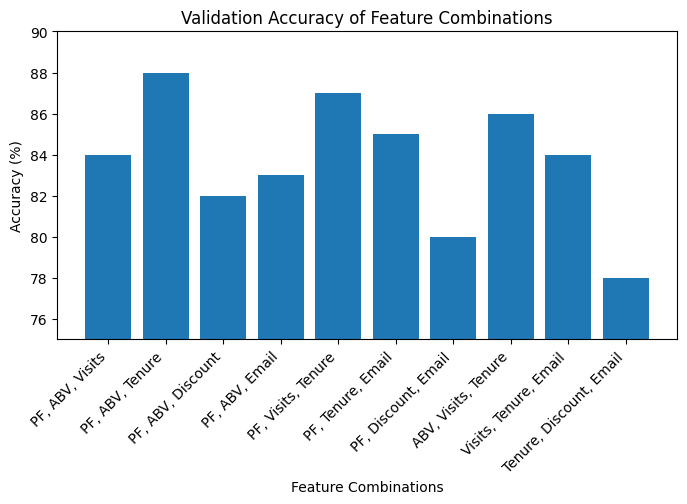

In [16]:
# Visualizing the accuracy of different feature combinations
plt.figure(figsize=(8,4))

plt.bar(df["Feature Combination"], df["Accuracy %"])

plt.title("Validation Accuracy of Feature Combinations")
plt.xlabel("Feature Combinations")
plt.ylabel("Accuracy (%)")
plt.ylim(75, 90)
plt.xticks(rotation=45, ha="right")

plt.show()

## **iv. Questions & Answers**

### **1. Use Exhaustive Search to identify the optimal feature subset.**

Exhaustive Search evaluates every possible combination of three features and compares their validation accuracies. Among all combinations, **Purchase Frequency (PF), Average Basket Value (ABV), and Customer Tenure** achieve the highest validation accuracy of **88%**. Therefore, this combination is selected as the optimal feature subset.


### **2. Why is Exhaustive Feature Selection considered computationally expensive?**

Exhaustive Feature Selection evaluates **every possible feature combination** before selecting the best subset. As the number of features increases, the number of possible combinations grows rapidly, resulting in higher computational time and memory requirements.

# **Case Study 4: Elastic Net Feature Selection**

### **Problem Statement**

A financial analytics company wants to predict stock returns using several highly correlated financial indicators. Since many of these features are correlated, the company chooses **Elastic Net Regression** for feature selection.

Elastic Net combines the strengths of both **Lasso (L1)** and **Ridge (L2)** regularization to select important features while handling multicollinearity.

### **Dataset**

| Feature | Description |
|---------|-------------|
| PE Ratio | Price-to-Earnings Ratio |
| PB Ratio | Price-to-Book Ratio |
| Debt Ratio | Debt-to-Equity Ratio |
| ROE | Return on Equity |
| ROA | Return on Assets |
| EPS | Earnings Per Share |
| Revenue Growth | Revenue Growth Rate |
| Margin | Profit Margin |
| Market Cap | Market Capitalization |
| Volume | Trading Volume |

### **Target Variable**

- Stock Returns

### **Elastic Net Parameters**

- α = 0.7
- λ = 0.8

### **Resulting Coefficients**

| Feature | Coefficient |
|---------|------------:|
| PE Ratio | 0.00 |
| PB Ratio | 0.00 |
| Debt Ratio | -0.34 |
| ROE | 0.62 |
| ROA | 0.00 |
| EPS | 0.51 |
| Revenue Growth | 0.00 |
| Margin | 0.44 |
| Market Cap | 0.02 |
| Volume | 0.00 |

### **Tasks**

1. Identify the selected features.
2. Explain why Elastic Net is preferred over Lasso for this problem.

## **i. Mathematical Computation**

Given:

$$
\alpha = 0.7,\qquad \lambda = 0.8
$$

Resulting Coefficients:

| Feature | Coefficient |
|---------|------------:|
| PE Ratio | 0 |
| PB Ratio | 0 |
| Debt Ratio | -0.34 |
| ROE | 0.62 |
| ROA | 0 |
| EPS | 0.51 |
| Revenue Growth | 0 |
| Margin | 0.44 |
| Market Cap | 0.02 |
| Volume | 0 |

Selected features have **non-zero coefficients**.

$$
\boxed{\{-0.34,\;0.62,\;0.51,\;0.44,\;0.02\}}
$$

Therefore, the selected features are

$$
\boxed{\{\text{Debt Ratio},\ \text{ROE},\ \text{EPS},\ \text{Margin},\ \text{Market Cap}\}}
$$

## **ii. Code Implementation**

Create a dataset containing the Elastic Net coefficients for all features.

In [17]:
# Creating a DataFrame for features and their corresponding coefficients
data = {
    "Feature": ["PE Ratio", "PB Ratio", "Debt Ratio", "ROE", "ROA",
                "EPS", "Revenue Growth", "Margin", "Market Cap", "Volume"],
    "Coefficient": [0, 0, -0.34, 0.62, 0, 0.51, 0, 0.44, 0.02, 0]
}

df = pd.DataFrame(data)
df

,Feature,Coefficient
0,PE Ratio,0.00
1,PB Ratio,0.00
2,Debt Ratio,-0.34
3,ROE,0.62
4,ROA,0.00
5,EPS,0.51
6,Revenue Growth,0.00
7,Margin,0.44
8,Market Cap,0.02
9,Volume,0.00


Select features with non-zero coefficients. Display the final features selected by Elastic Net.

In [18]:
# Selecting features with non-zero coefficients
selected = df[df["Coefficient"] != 0]
selected

,Feature,Coefficient
2,Debt Ratio,-0.34
3,ROE,0.62
5,EPS,0.51
7,Margin,0.44
8,Market Cap,0.02


In [19]:
# Displaying feature selection results
print("Total Features:", len(df))
print("Selected Features:", len(selected))
print(selected["Feature"].tolist())

print("Number of Features removed:", len(df) - len(selected))


Total Features: 10
Selected Features: 5
['Debt Ratio', 'ROE', 'EPS', 'Margin', 'Market Cap']
Number of Features removed: 5


## **iii. Visual Analysis**

The chart shows the coefficients assigned by the Elastic Net model. Features with **non-zero coefficients** are retained, while those with **zero coefficients** are eliminated. **ROE** has the highest positive coefficient, whereas **Debt Ratio** has the largest negative coefficient, indicating their strong influence on predicting stock returns.

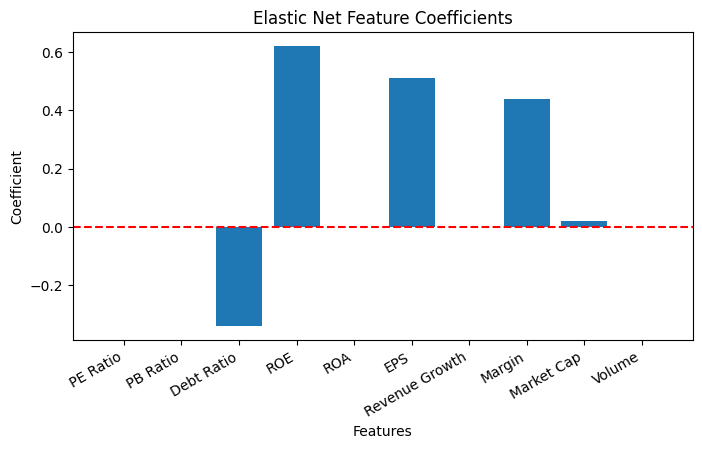

In [20]:
# Visualizing the coefficients of features after Elastic Net regularization
plt.figure(figsize=(8,4))

plt.bar(df["Feature"], df["Coefficient"])
plt.axhline(y=0, color='r', linestyle='--', label='Zero Coefficient')

plt.title("Elastic Net Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.xticks(rotation=30, ha="right")

plt.show()

## **iv. Questions & Answers**

### **1. Which features are selected?**

Elastic Net selects features with **non-zero coefficients**. The selected features are:

- Debt Ratio
- ROE
- EPS
- Margin
- Market Cap


### **2. Why is Elastic Net preferred over Lasso here?**

Elastic Net combines **L1 (Lasso)** and **L2 (Ridge)** regularization, making it more effective when features are **highly correlated**. Unlike Lasso, which may remove correlated features completely, Elastic Net can retain multiple relevant correlated features while reducing overfitting.

# **Case Study 5: Decision Tree Feature Importance**

### **Problem Statement**

A telecom company wants to predict customer churn using customer subscription and usage information. A **Decision Tree** model has been trained, and feature importance scores have been calculated.

The objective is to identify the **top 5 most important features** and remove the least important ones.

### **Dataset**

| Feature | Description |
|---------|-------------|
| Monthly Charges | Monthly subscription cost |
| Contract Type | Type of customer contract |
| Internet Type | Fiber, DSL, etc. |
| Tenure | Duration with the company |
| Support Calls | Number of customer support calls |
| Payment Method | Customer payment method |
| Streaming Services | Subscription to streaming services |

### **Target Variable**

- Customer Churn (Yes / No)

### **Decision Tree Feature Importance**

| Feature | Importance |
|---------|-----------:|
| Tenure | 0.34 |
| Contract Type | 0.28 |
| Monthly Charges | 0.18 |
| Support Calls | 0.11 |
| Internet Type | 0.05 |
| Payment Method | 0.03 |
| Streaming Services | 0.01 |

### **Task**

1. Select the **Top 5 features** based on feature importance.
2. Identify the features to be removed.

## **i. Mathematical Computation**

Feature Importance Scores:

| Feature | Importance |
|---------|-----------:|
| Tenure | 0.34 |
| Contract Type | 0.28 |
| Monthly Charges | 0.18 |
| Support Calls | 0.11 |
| Internet Type | 0.05 |
| Payment Method | 0.03 |
| Streaming Services | 0.01 |

#### **Step 1: Rank Features by Importance**

$$
0.34 > 0.28 > 0.18 > 0.11 > 0.05 > 0.03 > 0.01
$$

#### **Step 2: Select Top 5 Features**

$$
\boxed{\{\text{Tenure},\ \text{Contract Type},\ \text{Monthly Charges},\ \text{Support Calls},\ \text{Internet Type}\}}
$$

#### **Step 3: Remove Remaining Features**

$$
\boxed{\{\text{Payment Method},\ \text{Streaming Services}\}}
$$

#### **Feature Count**

Total Features: $7$

Selected Features: $5$

Removed Features: $2$

## **ii. Code Implementation**

Create a dataset containing the feature importance scores and sort the features based on importance in descending order.

In [21]:
# Creating a DataFrame for features and their corresponding importance scores
data = {
    "Feature": [
        "Tenure",
        "Contract Type",
        "Monthly Charges",
        "Support Calls",
        "Internet Type",
        "Payment Method",
        "Streaming Services"
    ],
    "Importance": [0.34, 0.28, 0.18, 0.11, 0.05, 0.03, 0.01]
}

df = pd.DataFrame(data)
df = df.sort_values(by="Importance", ascending=False).reset_index(drop=True)
df

,Feature,Importance
0,Tenure,0.34
1,Contract Type,0.28
2,Monthly Charges,0.18
3,Support Calls,0.11
4,Internet Type,0.05
5,Payment Method,0.03
6,Streaming Services,0.01


Select the top five most important features.

In [23]:
# Selecting the top 5 features based on importance scores
selected = df.head(5)
removed = df.tail(2)

selected

,Feature,Importance
0,Tenure,0.34
1,Contract Type,0.28
2,Monthly Charges,0.18
3,Support Calls,0.11
4,Internet Type,0.05


Display the selected and removed features.

In [24]:
print("Selected Features:", len(selected))
print(selected["Feature"].tolist())

print("\nRemoved Features:", len(removed))
print(removed["Feature"].tolist())

Selected Features: 5
['Tenure', 'Contract Type', 'Monthly Charges', 'Support Calls', 'Internet Type']

Removed Features: 2
['Payment Method', 'Streaming Services']


## **iii. Visual Analysis**

The chart ranks features according to their importance scores generated by the Decision Tree model. **Tenure** has the highest importance, followed by **Contract Type** and **Monthly Charges**. The top five features are retained for model building, while **Payment Method** and **Streaming Services** are excluded due to their relatively low importance scores.

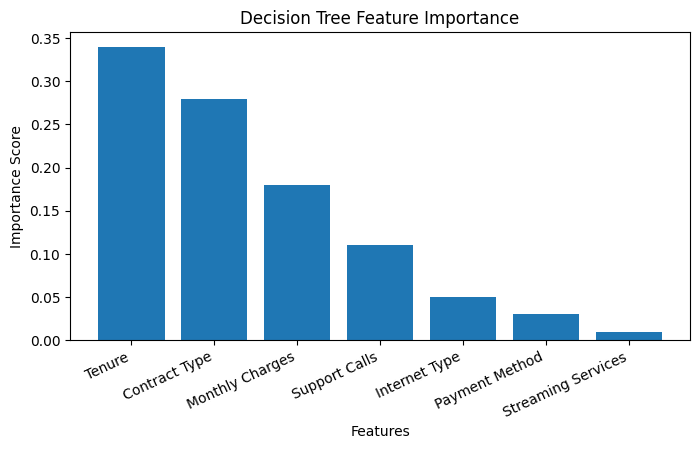

In [25]:
# Visualizing the feature importance scores from the Decision Tree model
plt.figure(figsize=(8,4))

plt.bar(df["Feature"], df["Importance"])

plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=25, ha="right")

plt.show()

## **iv. Questions & Answers**

### **1. Which features remain?**

The top five features with the highest importance scores are retained:

- Tenure
- Contract Type
- Monthly Charges
- Support Calls
- Internet Type

### **2. Which features are removed?**

The features with the lowest importance scores are removed:

- Payment Method
- Streaming Services

These features contribute the least to predicting customer churn and are therefore excluded from the final model.

# **Conclusion**

- **Case Study 1:** Forward Selection identified the best feature subset by maximizing the validation AUC.
- **Case Study 2:** Backward Elimination removed insignificant features and retained only statistically significant predictors.
- **Case Study 3:** Exhaustive Search evaluated all feature combinations and selected the subset with the highest accuracy.
- **Case Study 4:** Elastic Net retained important features with non-zero coefficients while handling correlated features effectively.
- **Case Study 5:** Decision Tree Feature Importance ranked features based on their contribution and selected the top five most important features.

---
### **Case Study Completed By:** Monish D.Y. - 230701195